# Faithful EfficientNetV2S reproduction of Mahmud et al. (ICCIT 2023)

**Goal:** reproduce the paper's EfficientNetV2S experiment and its **88.02% test accuracy** as closely as the public material allows.

This notebook intentionally does **not** add class weights, lesion-level splitting, uncertainty methods, referral analysis, frozen-backbone training, early stopping, or a new optimization strategy. Those belong to later extensions, not this graded reproduction.

Paper: *An Interpretable Deep Learning Approach for Skin Cancer Categorization*  
Official code: `Faysal-MD/An-Interpretable-Deep-Learning-Approach-for-Skin-Cancer-Categorization-IEEE2023`

## Read this before running

1. In Colab, select **Runtime -> Change runtime type -> T4 GPU**.
2. Open the **Secrets** panel using the key icon.
3. Add a secret named `KAGGLE_API_TOKEN`, paste your Kaggle token, and enable notebook access.
4. Run every cell from top to bottom without changing the default settings.
5. Budget roughly **2.5 to 3.5 hours** for 50 epochs on a T4.

### What cannot be copied exactly

The authors' repository begins by loading private `data.npy` and `labels.npy` files. It does not publish the code that created them, the exact resize interpolation, pixel scaling, package versions, complete seed, or trained checkpoint. The only reconstructed part here is creation of those arrays. We use metadata row order, 224 x 224 RGB images, raw `uint8` pixels, and one-hot labels in the authors' class order.

## 1. Setup and environment record

In [2]:
from __future__ import annotations

import json
import os
import platform
import random
import shutil
import subprocess
import sys
from pathlib import Path

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "kaggle", "tf-keras-vis"
])

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

SEED = 42  # The paper does not state a seed; 42 matches its split random_state.
IMAGE_SIZE = (224, 224)
NUM_CLASSES = 7
BATCH_SIZE = 16
EPOCHS = 50
PAPER_TEST_ACCURACY = 0.8802395462989807

CLASS_NAMES = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]
DX_TO_INDEX = {
    "akiec": 0, "bcc": 1, "bkl": 2, "df": 3,
    "mel": 4, "nv": 5, "vasc": 6,
}

ROOT = Path("/content/mahmud_efficientnetv2s_reproduction")
DOWNLOAD_DIR = ROOT / "download"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_NPY = ROOT / "data.npy"
LABELS_NPY = ROOT / "labels.npy"
CHECKPOINT = ARTIFACT_DIR / "EfficientNetV2S.h5"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
assert tf.config.list_physical_devices("GPU"), "Enable a GPU runtime before training."

Python: 3.13.15
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download HAM10000

This uses the common Kaggle mirror of HAM10000 because the authors' private Drive files are not public. The token is read from Colab Secrets and is never printed.

In [4]:
metadata_candidates = list(DOWNLOAD_DIR.rglob("HAM10000_metadata.csv"))

if not metadata_candidates:
    from google.colab import userdata

    token = userdata.get("KAGGLE_API_TOKEN")
    if not token:
        raise RuntimeError(
            "Add KAGGLE_API_TOKEN in Colab Secrets and enable notebook access."
        )

    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    token_path = kaggle_dir / "access_token"
    token_path.write_text(token)
    token_path.chmod(0o600)

    subprocess.check_call([
        "kaggle", "datasets", "download",
        "-d", "kmader/skin-cancer-mnist-ham10000",
        "-p", str(DOWNLOAD_DIR),
        "--unzip",
    ])

metadata_path = next(DOWNLOAD_DIR.rglob("HAM10000_metadata.csv"))
image_paths = list(DOWNLOAD_DIR.rglob("*.jpg"))
image_lookup = {path.stem: path for path in image_paths}

print("Metadata:", metadata_path)
print("JPG files found:", len(image_paths))

Metadata: /content/mahmud_efficientnetv2s_reproduction/download/HAM10000_metadata.csv
JPG files found: 20030


## 3. Reconstruct the missing `data.npy` and `labels.npy`

This is the only major step absent from the authors' repository. The metadata CSV row order is kept. Images are converted to RGB, resized to 224 x 224 with bilinear interpolation, and stored as raw `uint8` pixels.

EfficientNetV2S includes its input rescaling inside the Keras model by default. We therefore pass the raw pixels just as the released training notebook does.

In [5]:
metadata = pd.read_csv(metadata_path)
assert len(metadata) == 10015, f"Expected 10,015 rows, found {len(metadata)}"
assert set(metadata["dx"].unique()) == set(DX_TO_INDEX)

missing_ids = [image_id for image_id in metadata["image_id"] if image_id not in image_lookup]
assert not missing_ids, f"Missing {len(missing_ids)} images; first few: {missing_ids[:5]}"

if not DATA_NPY.exists() or not LABELS_NPY.exists():
    data_writer = np.lib.format.open_memmap(
        DATA_NPY,
        mode="w+",
        dtype=np.uint8,
        shape=(len(metadata), 224, 224, 3),
    )

    resample = Image.Resampling.BILINEAR
    for row_number, image_id in enumerate(metadata["image_id"]):
        with Image.open(image_lookup[image_id]) as image:
            image = image.convert("RGB").resize(IMAGE_SIZE, resample=resample)
            data_writer[row_number] = np.asarray(image, dtype=np.uint8)
        if (row_number + 1) % 1000 == 0:
            print(f"Prepared {row_number + 1:,}/{len(metadata):,} images")

    data_writer.flush()
    del data_writer

    integer_labels = metadata["dx"].map(DX_TO_INDEX).to_numpy()
    labels_to_save = to_categorical(integer_labels, num_classes=NUM_CLASSES).astype(np.float32)
    np.save(LABELS_NPY, labels_to_save)

data = np.load(DATA_NPY, mmap_mode="r")
labels = np.load(LABELS_NPY, mmap_mode="r")

print("Data shape:", data.shape, "dtype:", data.dtype, "range:", (data.min(), data.max()))
print("Labels shape:", labels.shape, "dtype:", labels.dtype)
print("Full class counts:", dict(zip(CLASS_NAMES, labels.sum(axis=0).astype(int))))

assert data.shape == (10015, 224, 224, 3)
assert labels.shape == (10015, 7)
assert data.dtype == np.uint8

Data shape: (10015, 224, 224, 3) dtype: uint8 range: (np.uint8(0), np.uint8(255))
Labels shape: (10015, 7) dtype: float32
Full class counts: {'AKIEC': np.int64(327), 'BCC': np.int64(514), 'BKL': np.int64(1099), 'DF': np.int64(115), 'MEL': np.int64(1113), 'NV': np.int64(6705), 'VASC': np.int64(142)}


## 4. Copy the authors' image-level split

The paper says 80:10:10. The released code first takes 10% for testing, then takes 10% of the remaining 90% for validation. That produces **8,111 train, 902 validation, and 1,002 test images**. We copy the released code because it is the executable record of their experiment.

This split is by image, not by `lesion_id`. That leakage risk is retained intentionally for reproduction and will be addressed only in later work.

In [6]:
all_indices = np.arange(len(data))

(
    train_data,
    test_data,
    train_labels,
    test_labels,
    train_indices,
    test_indices,
) = train_test_split(
    data,
    labels,
    all_indices,
    test_size=0.1,
    stratify=labels,
    random_state=42,
)

(
    train_data,
    val_data,
    train_labels,
    val_labels,
    train_indices,
    val_indices,
) = train_test_split(
    train_data,
    train_labels,
    train_indices,
    test_size=0.1,
    stratify=train_labels,
    random_state=42,
)

expected_sizes = {"train": 8111, "validation": 902, "test": 1002}
actual_sizes = {
    "train": len(train_data),
    "validation": len(val_data),
    "test": len(test_data),
}
assert actual_sizes == expected_sizes, (actual_sizes, expected_sizes)

split_counts = pd.DataFrame(
    {
        "train": train_labels.sum(axis=0).astype(int),
        "validation": val_labels.sum(axis=0).astype(int),
        "test": test_labels.sum(axis=0).astype(int),
    },
    index=CLASS_NAMES,
)
display(split_counts)

expected_counts = np.array([
    [264, 30, 33],
    [417, 46, 51],
    [890, 99, 110],
    [93, 10, 12],
    [902, 100, 111],
    [5430, 604, 671],
    [115, 13, 14],
])
assert np.array_equal(split_counts.to_numpy(), expected_counts), (
    "Class counts do not match the released notebook",
    split_counts.to_numpy(),
)

split_manifest = pd.concat([
    metadata.iloc[train_indices].assign(split="train"),
    metadata.iloc[val_indices].assign(split="validation"),
    metadata.iloc[test_indices].assign(split="test"),
]).sort_index()
split_manifest.to_csv(ARTIFACT_DIR / "split_manifest.csv", index_label="metadata_row")
print("The split sizes and every class count match the released notebook.")

,train,validation,test
AKIEC,264,30,33
BCC,417,46,51
BKL,890,99,110
DF,93,10,12
MEL,902,100,111
NV,5430,604,671
VASC,115,13,14


The split sizes and every class count match the released notebook.


## 5. Copy the authors' online augmentation

In [7]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

## 6. Copy the authors' EfficientNetV2S model

All EfficientNetV2S layers are trainable from the beginning. The ImageNet weights, head, dropout, optimizer, learning rate, loss, and metric match the released notebook.

In [6]:
base_model = EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

assert all(layer.trainable for layer in base_model.layers)
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 20,496,231 (78.19 MB)

 Trainable params: 20,342,359 (77.60 MB)

 Non-trainable params: 153,872 (601.06 KB)

## 7. Copy the authors' callbacks and 50-epoch training run

The released EfficientNetV2S notebook performs one continuous 50-epoch run. It saves the full model with the best validation accuracy and reduces the learning rate after five epochs without validation-accuracy improvement.

There is no early stopping, class weighting, backbone freezing, or second training stage.

In [7]:
model_checkpoint = ModelCheckpoint(
    str(CHECKPOINT),
    save_best_only=True,
    monitor="val_accuracy",
    verbose=1,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=5,
    mode="max",
    min_lr=1e-4,
    verbose=1,
)

history = model.fit(
    datagen.flow(train_data, train_labels, batch_size=BATCH_SIZE),
    validation_data=(val_data, val_labels),
    epochs=EPOCHS,
    callbacks=[model_checkpoint, reduce_lr],
)

history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)

model = load_model(CHECKPOINT)
print("Reloaded the best validation-accuracy checkpoint.")
display(history_df.tail())

Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.6440 - loss: 1.0558
Epoch 1: val_accuracy improved from None to 0.72506, saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5



Epoch 1: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 411s 484ms/step - accuracy: 0.6878 - loss: 0.9131 - val_accuracy: 0.7251 - val_loss: 0.8426 - learning_rate: 0.0010
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7380 - loss: 0.7507
Epoch 2: val_accuracy improved from 0.72506 to 0.79379, saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5



Epoch 2: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 149s 294ms/step - accuracy: 0.7402 - loss: 0.7459 - val_accuracy: 0.7938 - val_loss: 0.6708 - learning_rate: 0.0010
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.7537 - loss: 0.7120
Epoch 3: val_accuracy did not improve from 0.79379
507/507 ━━━━━━━━━━━━━━━━━━━━ 141s 278ms/step - accuracy: 0.7498 - loss: 0.6977 - val_accuracy: 0.7827 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.7543 - loss: 0.6789
Epoch 4: val_accuracy did not improve from 0.79379
507/507 ━━━━━━━━━━━━━━━━━━━━ 143s 281ms/step - accuracy: 0.7686 - loss: 0.6534 - val_accuracy: 0.7838 - val_loss: 0.5960 - learning_rate: 0.0010
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.7741 - loss: 0.6357
Epoch 5: val_accuracy did not improve from 0.79379
507/507 ━━━━━━━━━━━━━━━━━━━━ 140s 276ms


Epoch 6: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 165s 325ms/step - accuracy: 0.7911 - loss: 0.5809 - val_accuracy: 0.8016 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 7/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8028 - loss: 0.5532
Epoch 7: val_accuracy did not improve from 0.80155
507/507 ━━━━━━━━━━━━━━━━━━━━ 142s 281ms/step - accuracy: 0.7958 - loss: 0.5639 - val_accuracy: 0.7938 - val_loss: 0.6155 - learning_rate: 0.0010
Epoch 8/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8043 - loss: 0.5240
Epoch 8: val_accuracy improved from 0.80155 to 0.80377, saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5



Epoch 8: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 179s 352ms/step - accuracy: 0.8072 - loss: 0.5283 - val_accuracy: 0.8038 - val_loss: 0.5550 - learning_rate: 0.0010
Epoch 9/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8128 - loss: 0.5234
Epoch 9: val_accuracy improved from 0.80377 to 0.82594, saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5


...


Epoch 40: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 167s 329ms/step - accuracy: 0.9618 - loss: 0.1068 - val_accuracy: 0.8880 - val_loss: 0.5304 - learning_rate: 5.0000e-04
Epoch 41/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9651 - loss: 0.1007
Epoch 41: val_accuracy did not improve from 0.88803
507/507 ━━━━━━━━━━━━━━━━━━━━ 137s 270ms/step - accuracy: 0.9644 - loss: 0.1048 - val_accuracy: 0.8758 - val_loss: 0.5220 - learning_rate: 5.0000e-04
Epoch 42/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9659 - loss: 0.1032
Epoch 42: val_accuracy did not improve from 0.88803
507/507 ━━━━━━━━━━━━━━━━━━━━ 137s 271ms/step - accuracy: 0.9618 - loss: 0.1085 - val_accuracy: 0.8792 - val_loss: 0.5486 - learning_rate: 5.0000e-04
Epoch 43/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9690 - loss: 0.0908
Epoch 43: val_accuracy did not improve from 0.88803
507/507 ━━━━━━━━━━━━


Epoch 47: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 169s 334ms/step - accuracy: 0.9820 - loss: 0.0562 - val_accuracy: 0.8891 - val_loss: 0.6049 - learning_rate: 2.5000e-04
Epoch 48/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9836 - loss: 0.0471
Epoch 48: val_accuracy improved from 0.88914 to 0.89357, saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5



Epoch 48: finished saving model to /content/mahmud_efficientnetv2s_reproduction/artifacts/EfficientNetV2S.h5
507/507 ━━━━━━━━━━━━━━━━━━━━ 172s 339ms/step - accuracy: 0.9836 - loss: 0.0489 - val_accuracy: 0.8936 - val_loss: 0.6114 - learning_rate: 2.5000e-04
Epoch 49/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9879 - loss: 0.0364
Epoch 49: val_accuracy did not improve from 0.89357
507/507 ━━━━━━━━━━━━━━━━━━━━ 138s 271ms/step - accuracy: 0.9863 - loss: 0.0430 - val_accuracy: 0.8858 - val_loss: 0.5810 - learning_rate: 2.5000e-04
Epoch 50/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9871 - loss: 0.0382
Epoch 50: val_accuracy did not improve from 0.89357
507/507 ━━━━━━━━━━━━━━━━━━━━ 139s 274ms/step - accuracy: 0.9862 - loss: 0.0406 - val_accuracy: 0.8891 - val_loss: 0.5877 - learning_rate: 2.5000e-04


Reloaded the best validation-accuracy checkpoint.


,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
45,46,0.977068,0.069250,0.880266,0.571683,0.00025
46,47,0.982000,0.056169,0.889135,0.604864,0.00025
47,48,0.983603,0.048943,0.893570,0.611358,0.00025
48,49,0.986315,0.042994,0.885809,0.581044,0.00025
49,50,0.986192,0.040609,0.889135,0.587650,0.00025


## 8. Test evaluation and comparison with the paper

The test set remains untouched until this point. We calculate the same main outputs: test accuracy, classification report, confusion matrix, and one-vs-rest ROC curves.

In [8]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels, batch_size=32, verbose=1)
probabilities = model.predict(test_data, batch_size=32, verbose=1)
predicted_labels = probabilities.argmax(axis=1)
true_labels = test_labels.argmax(axis=1)

report = classification_report(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df)

difference_pp = abs(test_accuracy - PAPER_TEST_ACCURACY) * 100
comparison = {
    "paper_test_accuracy": PAPER_TEST_ACCURACY,
    "reproduced_test_accuracy": float(test_accuracy),
    "absolute_difference_percentage_points": float(difference_pp),
    "test_loss": float(test_loss),
}

print(f"Paper test accuracy:      {PAPER_TEST_ACCURACY:.4%}")
print(f"Reproduced test accuracy: {test_accuracy:.4%}")
print(f"Absolute difference:      {difference_pp:.2f} percentage points")

with open(ARTIFACT_DIR / "metrics.json", "w") as file:
    json.dump(comparison, file, indent=2)
report_df.to_csv(ARTIFACT_DIR / "classification_report.csv")

prediction_table = metadata.iloc[test_indices][["image_id", "lesion_id", "dx"]].copy()
prediction_table["true_index"] = true_labels
prediction_table["predicted_index"] = predicted_labels
prediction_table["predicted_class"] = [CLASS_NAMES[index] for index in predicted_labels]
for class_index, class_name in enumerate(CLASS_NAMES):
    prediction_table[f"prob_{class_name}"] = probabilities[:, class_index]
prediction_table.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 302ms/step - accuracy: 0.8952 - loss: 0.4603
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 435ms/step


,precision,recall,f1-score,support
AKIEC,0.900000,0.545455,0.679245,33.00000
BCC,0.916667,0.862745,0.888889,51.00000
BKL,0.725191,0.863636,0.788382,110.00000
DF,0.846154,0.916667,0.880000,12.00000
MEL,0.806818,0.639640,0.713568,111.00000
NV,0.938953,0.962742,0.950699,671.00000
VASC,0.857143,0.857143,0.857143,14.00000
accuracy,0.895210,0.895210,0.895210,0.89521
macro avg,0.855847,0.806861,0.822561,1002.00000
weighted avg,0.896177,0.895210,0.892371,1002.00000


Paper test accuracy:      88.0240%
Reproduced test accuracy: 89.5210%
Absolute difference:      1.50 percentage points


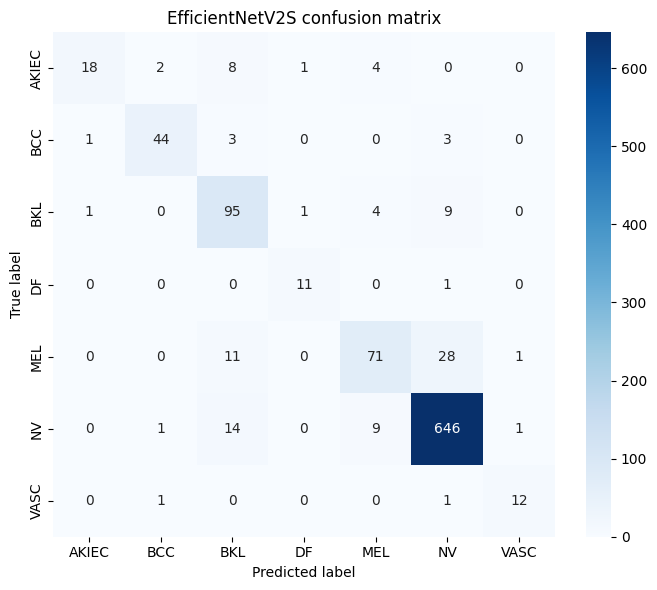

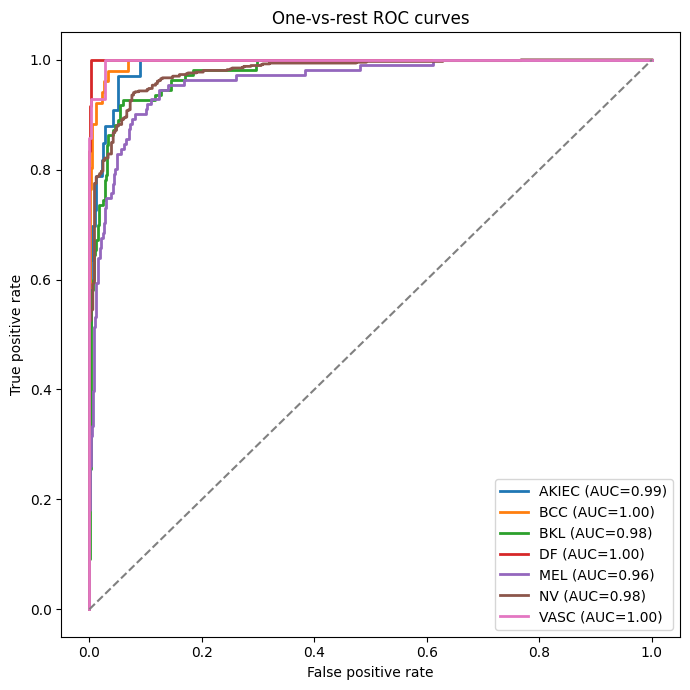

In [9]:
matrix = confusion_matrix(true_labels, predicted_labels, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("EfficientNetV2S confusion matrix")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix.png", dpi=180)
plt.show()

plt.figure(figsize=(7, 7))
for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(test_labels[:, class_index], probabilities[:, class_index])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC={class_auc:.2f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("One-vs-rest ROC curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_curves.png", dpi=180)
plt.show()